In [1]:
# %matplotlib widget

import matplotlib.pyplot as plt
import matplotlib.image as img
import numpy as np
import os
import warnings

from copy import copy
from obspy.core import UTCDateTime
from pysep import Pysep
from pysep.recsec import plotw_rs
from obspy import read, read_events, read_inventory
from pysep.utils.cap_sac import append_sac_headers, format_sac_header_w_taup_traveltimes, write_cap_weights_files
# script settings

warnings.filterwarnings("ignore")
plt.rcParams['figure.figsize'] = 9, 6

In [2]:
def fetch_and_plot(event, duration, download, plotting, bandpass):

    '''
    - downloads seismograms and plot them in a record section based on user inputs
    - also plots a source station map corresponding to the downloaded data
    - uses PySEP's data download and record section plotting utilities for the same
    - does not download data if the output data directory already exists
    '''

    '''
    :type event: dict
    :param event: event details
    :type duration: dict
    :param duration: time range for for data requested
    :type download: dict
    :param download: data download parameters
    :type plotting: dict
    :param plotting: record section plotting parameters
    :type bandpass: dict
    :param bandpass: bandpass filter parameters
    '''

    # download data
    data_dir  = f'{download["output_dir"]}/{download["overwrite_event_tag"]}'
    overwrite = f'{download["overwrite"]}'

    if (not os.path.isdir(data_dir)) or (overwrite == 'True'):
        print('\npreparing to download data ....')
        ps = Pysep(**event,**duration,**download)
        ps.run()
    else:
        print('\ndata directory already exists, no data will be downloaded')


    # plot source station map
    print('plotting source station map ....')
    plt.figure()
    source_station_map = img.imread(f'{data_dir}/station_map.png')
    plt.imshow(source_station_map)
    plt.show()

In [3]:
# setting pysep's data download defaults

# list of networks to retrieve data from
# providing an explicit list of networks is safer than using the wildcard (*)
networks            = ('G,IC,II,IU') #No space btw each network 

download_defaults   = dict( networks                     = networks,
                            stations                     = '*',
                            locations                    = '00',
                            channels                     = 'BHZ',
                            maxdistance_km               = 1300,
                            remove_clipped               = False,
                            remove_insufficient_length   = False,
                            fill_data_gaps               = 0,
                            rotate                       = {'RTZ'},
                            remove_response              = True,
                            output_unit                  = 'DISP',
                            log_level                    = 'INFO',
                            plot_files                   = 'map',
                            output_dir                   = '/Users/u7091895/Documents/Research/BayMTI/HiBaysin/data',
                            sac_subdir                   = '',
                            overwrite_event_tag          = f'',
                            write_files                  = 'weights_code,sac_rtz',
                            # resample_freq                = 1,
                            overwrite                    = True )

# setting pysep's record section plotting defaults

plotting_defaults   = dict( pysep_path                   = '',
                            sort_by                      = 'distance',
                            scale_by                     = 'normalize',
                            amplitude_scale_factor       = 1,
                            time_shift_s                 = None,
                            preprocess                   = 'st',
                            max_traces_per_rs            = None,
                            distance_units               = 'km',
                            tmarks                       = [0],
                            dpi                          = 300,
                            save                         = '',
                            log_level                    = 'CRITICAL' )

# Download broadband data for DPRK2013 test

[2025-08-20 21:12:50] - pysep - INFO: creating event metadata with user parameters
[2025-08-20 21:12:50] - pysep - INFO: event info summary - origin time: 2013-02-12T02:57:51.000000Z; lat=41.29; lon=129.07; depth[km]=0.5; magnitude=4.9
[2025-08-20 21:12:50] - pysep - INFO: full output directory is: Data/20130212025751000
[2025-08-20 21:12:50] - pysep - INFO: querying IRIS for station metadata



preparing to download data ....


[2025-08-20 21:14:00] - pysep - INFO: collected 563 channels from 180 stations in 6 networks from IRIS
[2025-08-20 21:14:02] - pysep - INFO: 167 traces outside distance bounds [0, 1300]km
[2025-08-20 21:14:02] - pysep - INFO: 0 traces outside azimuth bounds [0, 360]deg
[2025-08-20 21:14:02] - pysep - INFO: querying client 'IRIS' for waveforms
[2025-08-20 21:14:02] - pysep - INFO: querying 13 lines in bulk client request...
[2025-08-20 21:14:44] - pysep - INFO: 21 waveforms returned after query
[2025-08-20 21:14:44] - pysep - INFO: cleaning up channel naming
[2025-08-20 21:14:49] - pysep - INFO: applying linear detrend to all data
[2025-08-20 21:14:49] - pysep - INFO: removing response, output units in: DISP
[2025-08-20 21:14:49] - pysep - INFO: will apply pre-filter: default
[2025-08-20 21:14:52] - pysep - INFO: applying amplitude scale factor: 1
[2025-08-20 21:14:52] - pysep - INFO: resampling data to sampling rate: 1Hz with method 'interpolate'
[2025-08-20 21:14:53] - pysep - INFO: t

plotting source station map ....


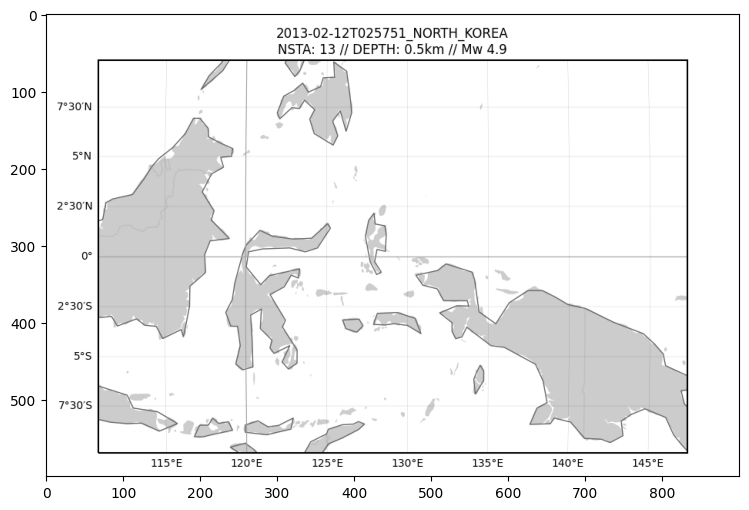

In [13]:
# event information could not be found on catalog

download   = copy(download_defaults)
plotting   = copy(plotting_defaults)

#Based on GA 
event      = dict( origin_time                  = UTCDateTime("2013,2,12,2,57,51"),
                   event_latitude               = 41.2921,
                   event_longitude              = 129.0730,
                   event_depth_km               = 0.5,
                   event_magnitude              = 4.9 )

duration   = dict( seconds_before_ref           = 3600, #reference time is origin time here
                   seconds_after_ref            = 3600 )

download['channels']                            = 'BHZ,BHN,BHE,BH1,BH2' #No space btw each channel code
download['overwrite_event_tag']                 = '20130212025751000'

bandpass   = dict( min_period_s                 = 20,
                   max_period_s                 = 50 )

plotting["pysep_path"]                          = f'{download["output_dir"]}/{download["overwrite_event_tag"]}'

fetch_and_plot(event, duration, download, plotting, bandpass)

In [ ]:
st = read('/Users/u7091895/Documents/Research/BayMTI/HiBaysin/data/DPRK2013/*BHZ*.sac')
plotw_rs(st=st, cale_by="normalize", scale_by            = 'normalize',
                            amplitude_scale_factor       = 1,
                            time_shift_s                 = None,
                            preprocess                   = 'st',
                            max_traces_per_rs            = None,
                            distance_units               = 'km', 
                            overwrite                    = True,
                            sort_by                    = 'distance',
                            **bandpass)


In [10]:
from obspy.io.sac import SACTrace
from obspy.geodetics import gps2dist_azimuth
# write_cap_weights_files(st, path_out='./', order_by='dist')
origin = UTCDateTime("2013,2,12,2,57,51")
st=read("/Volumes/ABD/SharedData/DPRK_Data/20130212/Displacement/KG.CHNB..BH?.20130212000000.disp.rmResp.mseed")
st.rotate('NE->RT', back_azimuth=25.8747)
st.resample(sampling_rate=1)
st.trim(origin-3600, origin+3600-0.01)

sta_la = 38.27100
sta_lo = 127.12120
evt_lat = 41.2921
evt_lon = 129.0730

b = st[0].stats.starttime - origin

dist, az, baz = gps2dist_azimuth(evt_lat, evt_lon, sta_la, sta_lo)

npts = st[0].stats.npts
delta = st[0].stats.delta
sac_Z = SACTrace(
    npts=npts,
    delta=delta,
    b=b,                          # begin time of trace in seconds
    e=(npts - 1) * delta,         # end time
    knetwk= 'KG',                 # station network
    kstnm='CHNB',                 # station name
    kcmpnm='BHZ',                 # component name
    khole='00',
    stla=sta_la,                  # station latitude
    stlo=sta_lo,                  # station longitude
    evla=evt_lat,                 # event latitude
    evlo=evt_lon,                 # event longitude
    evdp=0.5,                     # event depth (km)
    # o=0,                          # origin time relative to trace start
    #origin time
    nzyear=origin.year,
    nzjday=origin.julday,
    nzhour=origin.hour,
    nzmin=origin.minute,
    nzsec=origin.second,
    nzmsec=origin.microsecond // 1000,
    mag=4.9,
    dist=dist*0.001,     #great circle distance in km
    az=az,                   #source-station azimuth
    baz=baz,             #station-source back azimuth
)

sac_R = SACTrace(
    npts=npts,
    delta=delta,
    b=b,                          # begin time of trace in seconds
    e=(npts - 1) * delta,         # end time
    knetwk= 'KG',                 # station network
    kstnm='CHNB',                 # station name
    kcmpnm='BHR',                 # component name
    khole='00',
    stla=sta_la,                  # station latitude
    stlo=sta_lo,                  # station longitude
    evla=evt_lat,                 # event latitude
    evlo=evt_lon,                 # event longitude
    evdp=0.5,                     # event depth (km)
    # o=0,                          # origin time relative to trace start
    #origin time
    nzyear=origin.year,
    nzjday=origin.julday,
    nzhour=origin.hour,
    nzmin=origin.minute,
    nzsec=origin.second,
    nzmsec=origin.microsecond // 1000,
    mag=4.9,
    dist=dist*0.001,     #great circle distance in km
    az=az,                   #source-station azimuth
    baz=baz,             #station-source back azimuth
)

sac_T = SACTrace(
    npts=npts,
    delta=delta,
    b=b,                          # begin time of trace in seconds
    e=(npts - 1) * delta,         # end time
    knetwk= 'KG',                 # station network
    kstnm='CHNB',                 # station name
    kcmpnm='BHT',                 # component name
    khole='00',
    stla=sta_la,                  # station latitude
    stlo=sta_lo,                  # station longitude
    evla=evt_lat,                 # event latitude
    evlo=evt_lon,                 # event longitude
    evdp=0.5,                     # event depth (km)
    # o=0,                          # origin time relative to trace start
    #origin time
    nzyear=origin.year,
    nzjday=origin.julday,
    nzhour=origin.hour,
    nzmin=origin.minute,
    nzsec=origin.second,
    nzmsec=origin.microsecond // 1000,
    mag=4.9,
    dist=dist*0.001,         #great circle distance in km
    az=az,                   #source-station azimuth
    baz=baz,                 #station-source back azimuth
)

sac_Z.data = st.select(channel="BHZ")[0].data
sac_R.data = st.select(channel="BHR")[0].data
sac_T.data = st.select(channel="BHT")[0].data

sac_Z.write( "20130212025751000.KG.CHNB.00.BHZ.sac")
sac_R.write( "20130212025751000.KG.CHNB.00.BHR.sac")
sac_T.write( "20130212025751000.KG.CHNB.00.BHT.sac")

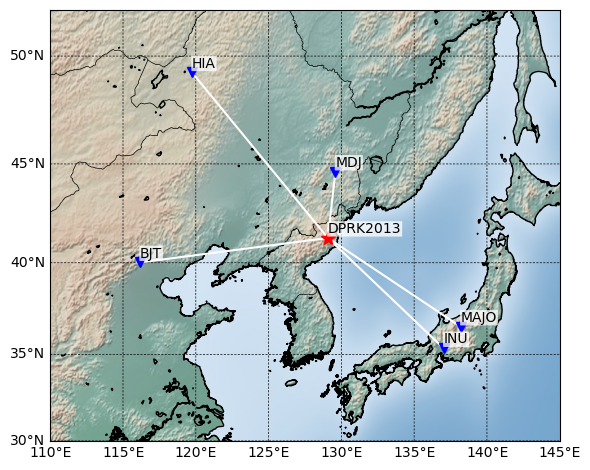

In [11]:
from IO import read_stations, read_event
from mpl_toolkits.basemap import Basemap
## PLOTTING STATION-EVENT CONFIGURATION MAP
evname = '2013'
evdp = 500
stations = read_stations('DPRK2013_iris.config')
origin = read_event(evla=41.2921, evlo=129.073, evdp=evdp*1e-3)

## MAP BACKGROUND
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

m = Basemap(projection='merc',llcrnrlat=30,urcrnrlat=52,\
            llcrnrlon=110,urcrnrlon=145,lat_ts=39,resolution='h', ax=ax)
m.shadedrelief()
m.drawcoastlines()
m.drawcountries()
m.drawparallels(np.arange(30, 52.,5.), dashes=[3, 2], linewidth=.5, labels=[1,0,0,0])
m.drawmeridians(np.arange(110, 145.5,5.), dashes=[3, 2], linewidth=.5, labels=[0,0,0,1])
# ## LOCATION OF NUCLEAR TESTS
xx_0, yy_0 = m(origin.longitude, origin.latitude)
## LOCATION OF STATIONS
xx, yy = m([s.longitude for s in stations], [s.latitude for s in stations])

for x, y, s in zip(xx, yy, [s.station for s in stations]):
    plt.plot([xx_0,x],[yy_0,y], color = 'white')
    if s == 'YNCB':
        plt.text(x, y-60e3, s, bbox={'boxstyle':'round', 'pad':0.05, 'color':'w', 'ec':'none', 'alpha':0.75})
    else:
        plt.text(x, y+30e3, s, bbox={'boxstyle':'round', 'pad':0.05, 'color':'w', 'ec':'none', 'alpha':0.75})
plt.plot(xx, yy, 'v', color='b', markersize=7)    
plt.plot(xx_0, yy_0, '*', color='r', markersize=10)
plt.text(xx_0, yy_0+30e3, 'DPRK'+evname, bbox={'boxstyle':'round', 'pad':0.05, 'color':'w', 'ec':'none', 'alpha':0.75})
plt.tight_layout()
plt.show()

In [3]:
## PREPARE DATA TO THE FORMAT CONVENIENTLY USED IN EMCEE

# CPS is a library that I prepare to calculate Green's function on the fly using CPS code
from CPS import generate_CPS_greens_tensor
origin = read_event(evla=41.2921, evlo=129.073, evdp=0.5)

# kim11 is a 1D earth model in plain format
path_to_earth_model = 'MDJ2'
path_to_CPS_greens_tensor = 'MDJ2_%dm' % origin.depth_in_m
generate_CPS_greens_tensor(origin, stations, path_to_earth_model, t0=0, vred=0)


    Generating Greens's function with CPS

/Users/u7091895/Documents/Research/BayMTI/HiBaysin/examples/MDJ2.mod


# Download broadband data for DPRK2017 test

## download data

[2025-10-01 11:29:43] - pysep - INFO: creating event metadata with user parameters
[2025-10-01 11:29:43] - pysep - INFO: event info summary - origin time: 2017-09-03T03:38:31.000000Z; lat=41.30; lon=129.08; depth[km]=0.5; magnitude=5.24
[2025-10-01 11:29:43] - pysep - INFO: full output directory is: /Users/u7091895/Documents/Research/BayMTI/HiBaysin/data/20170903033831000
[2025-10-01 11:29:43] - pysep - INFO: querying IRIS for station metadata



preparing to download data ....


[2025-10-01 11:30:24] - pysep - INFO: collected 476 channels from 159 stations in 4 networks from IRIS
[2025-10-01 11:30:25] - pysep - INFO: 151 traces outside distance bounds [0, 1300]km
[2025-10-01 11:30:25] - pysep - INFO: 0 traces outside azimuth bounds [0, 360]deg
[2025-10-01 11:30:25] - pysep - INFO: querying client 'IRIS' for waveforms
[2025-10-01 11:30:25] - pysep - INFO: querying 8 lines in bulk client request...
[2025-10-01 11:31:21] - pysep - INFO: 24 waveforms returned after query
[2025-10-01 11:31:21] - pysep - INFO: cleaning up channel naming
[2025-10-01 11:31:27] - pysep - INFO: applying linear detrend to all data
[2025-10-01 11:31:27] - pysep - INFO: removing response, output units in: DISP
[2025-10-01 11:31:27] - pysep - INFO: will apply pre-filter: default
[2025-10-01 11:31:29] - pysep - INFO: applying amplitude scale factor: 1
[2025-10-01 11:31:29] - pysep - INFO: trimming start and end times on a per-station basis
[2025-10-01 11:31:29] - pysep - INFO: formatting str

plotting source station map ....


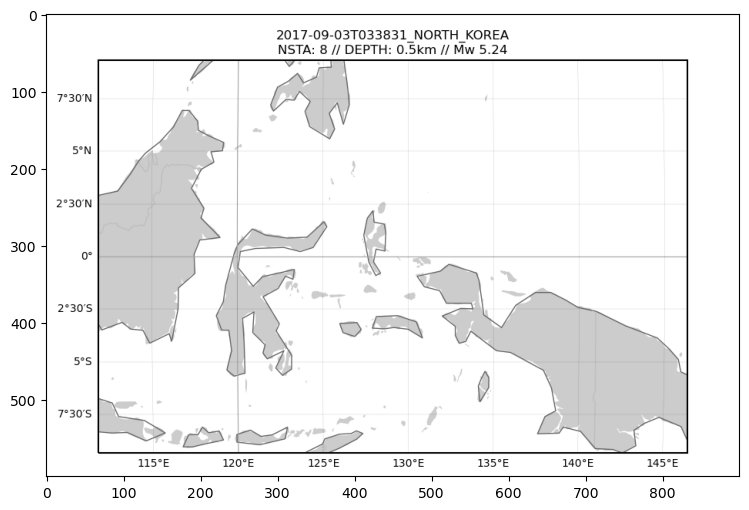

In [17]:
# event information could not be found on catalog

download   = copy(download_defaults)
plotting   = copy(plotting_defaults)

#Based on GA 
event      = dict( origin_time                  = UTCDateTime("2017,9,3,3,38,31"),
                   event_latitude               = 41.3,
                   event_longitude              = 129.078,
                   event_depth_km               = 0.5,
                   event_magnitude              = 5.24 )

duration   = dict( seconds_before_ref           = 3600, #reference time is origin time here
                   seconds_after_ref            = 3600 )

download['channels']                            = 'BHZ,BHN,BHE,BH1,BH2' #No space btw each channel code
download['overwrite_event_tag']                 = '20170903033831000'

bandpass   = dict( min_period_s                 = 20,
                   max_period_s                 = 50 )

plotting["pysep_path"]                          = f'{download["output_dir"]}/{download["overwrite_event_tag"]}'

fetch_and_plot(event, duration, download, plotting, bandpass)

## plot data section

[2025-10-01 11:36:35] - pysep - INFO: starting record section plotter
[2025-10-01 11:36:35] - pysep - INFO: checking parameter acceptability
[2025-10-01 11:36:35] - pysep - INFO: getting source-receiver stats
[2025-10-01 11:36:35] - pysep - INFO: calculating source-receiver distance and (back)azimuths
[2025-10-01 11:36:35] - pysep - INFO: preprocessing 8 `st` waveforms
[2025-10-01 11:36:35] - pysep - INFO: applying bandpass filter w/ [0.02, 20]
[2025-10-01 11:36:35] - pysep - INFO: calculating starttime offsets from event origin time 2017-09-03T03:38:31.000000Z
[2025-10-01 11:36:35] - pysep - INFO: determining sort order with parameter: distance
[2025-10-01 11:36:35] - pysep - INFO: determining if any stations/channels should be skipped
[2025-10-01 11:36:35] - pysep - INFO: criteria check will remove 0/8 traces
[2025-10-01 11:36:35] - pysep - INFO: determining y-axis positioning for sort: distance
[2025-10-01 11:36:35] - pysep - INFO: determining amplitude scaling w.r.t st with: 'norma

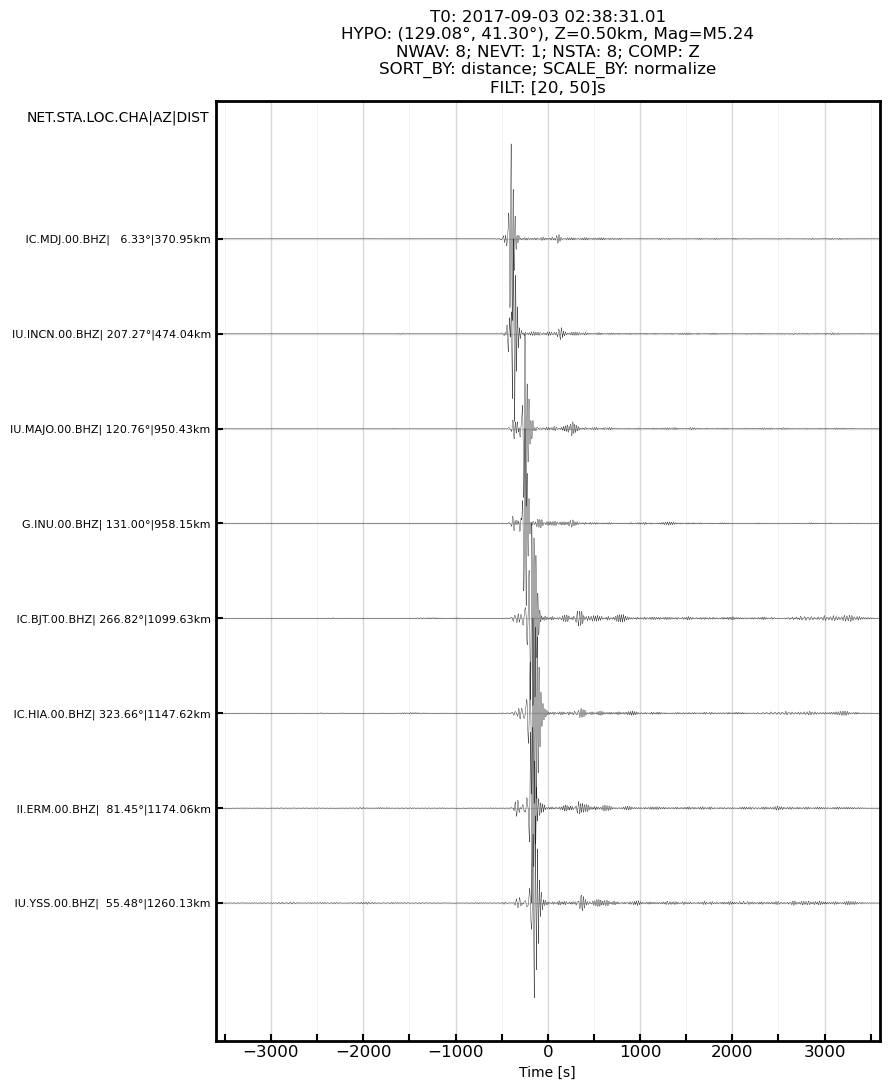

[2025-10-01 11:36:36] - pysep - INFO: finished record section in t=0:00:00.692878s


In [22]:
st = read(plotting["pysep_path"]+'/*BHZ*.sac')
plotw_rs(st=st, cale_by="normalize", scale_by            = 'normalize',
                            amplitude_scale_factor       = 1,
                            time_shift_s                 = None,
                            preprocess                   = 'st',
                            max_traces_per_rs            = None,
                            distance_units               = 'km', 
                            overwrite                    = True,
                            sort_by                    = 'distance',
                            **bandpass)

## Compute Green's functions

In [22]:
# CPS is a library that I prepare to calculate Green's function on the fly using CPS code
from CPS import generate_CPS_greens_tensor
from IO import read_stations, read_event

stations = read_stations('DPRK2017_iris.config')
origin = read_event(evla=41.3, evlo=129.078, evdp=0.5)

path_to_earth_model = 'MDJ2'
generate_CPS_greens_tensor(origin, stations, path_to_earth_model, t0=0, vred=0)


    Generating Greens's function with CPS

/Users/u7091895/Documents/Research/BayMTI/HiBaysin/examples/MDJ2.mod


# Download broadband data for DPRK2016a test


preparing to download data ....


[2025-10-01 12:00:54] - pysep - INFO: creating event metadata with user parameters
[2025-10-01 12:00:54] - pysep - INFO: event info summary - origin time: 2016-01-06T01:30:00.000000Z; lat=41.30; lon=129.07; depth[km]=0.5; magnitude=4.48
[2025-10-01 12:00:54] - pysep - INFO: full output directory is: /Users/u7091895/Documents/Research/BayMTI/HiBaysin/data/20160106013000000
[2025-10-01 12:00:54] - pysep - INFO: querying IRIS for station metadata
[2025-10-01 12:01:37] - pysep - INFO: collected 466 channels from 157 stations in 4 networks from IRIS
[2025-10-01 12:01:38] - pysep - INFO: 149 traces outside distance bounds [0, 1300]km
[2025-10-01 12:01:38] - pysep - INFO: 0 traces outside azimuth bounds [0, 360]deg
[2025-10-01 12:01:38] - pysep - INFO: querying client 'IRIS' for waveforms
[2025-10-01 12:01:38] - pysep - INFO: querying 8 lines in bulk client request...
[2025-10-01 12:02:33] - pysep - INFO: 24 waveforms returned after query
[2025-10-01 12:02:33] - pysep - INFO: cleaning up chan

plotting source station map ....


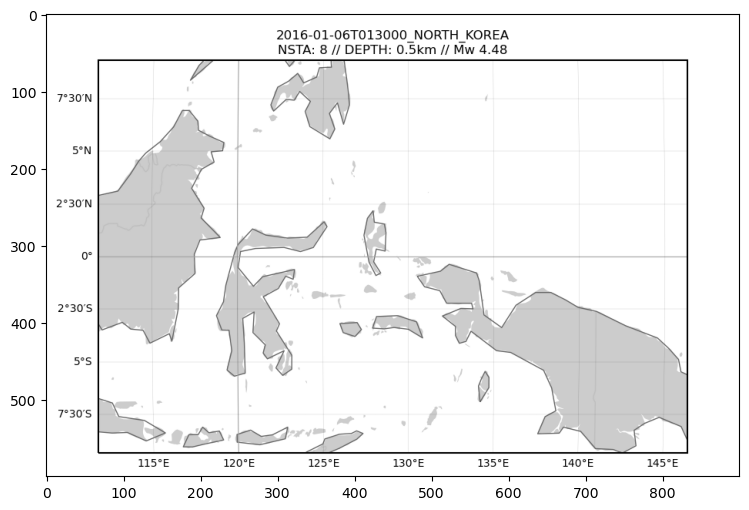

In [8]:
# event information could not be found on catalog

download   = copy(download_defaults)
plotting   = copy(plotting_defaults)

#Based on GA 
event      = dict( origin_time                  = UTCDateTime("2016,1,6,1,30,0"),
                   event_latitude               = 41.3001,
                   event_longitude              = 129.0680,
                   event_depth_km               = 0.5,
                   event_magnitude              = 4.48 )

duration   = dict( seconds_before_ref           = 3600, #reference time is origin time here
                   seconds_after_ref            = 3600 )

download['channels']                            = 'BHZ,BHN,BHE,BH1,BH2' #No space btw each channel code
download['overwrite_event_tag']                 = '20160106013000000'

bandpass   = dict( min_period_s                 = 20,
                   max_period_s                 = 50 )

plotting["pysep_path"]                          = f'{download["output_dir"]}/{download["overwrite_event_tag"]}'

fetch_and_plot(event, duration, download, plotting, bandpass)

[2025-10-01 12:03:46] - pysep - INFO: starting record section plotter
[2025-10-01 12:03:46] - pysep - INFO: checking parameter acceptability
[2025-10-01 12:03:46] - pysep - INFO: getting source-receiver stats
[2025-10-01 12:03:46] - pysep - INFO: calculating source-receiver distance and (back)azimuths
[2025-10-01 12:03:46] - pysep - INFO: preprocessing 8 `st` waveforms
[2025-10-01 12:03:46] - pysep - INFO: applying bandpass filter w/ [0.02, 20]
[2025-10-01 12:03:46] - pysep - INFO: calculating starttime offsets from event origin time 2016-01-06T01:30:00.000000Z
[2025-10-01 12:03:46] - pysep - INFO: determining sort order with parameter: distance
[2025-10-01 12:03:46] - pysep - INFO: determining if any stations/channels should be skipped
[2025-10-01 12:03:46] - pysep - INFO: criteria check will remove 0/8 traces
[2025-10-01 12:03:46] - pysep - INFO: determining y-axis positioning for sort: distance
[2025-10-01 12:03:46] - pysep - INFO: determining amplitude scaling w.r.t st with: 'norma

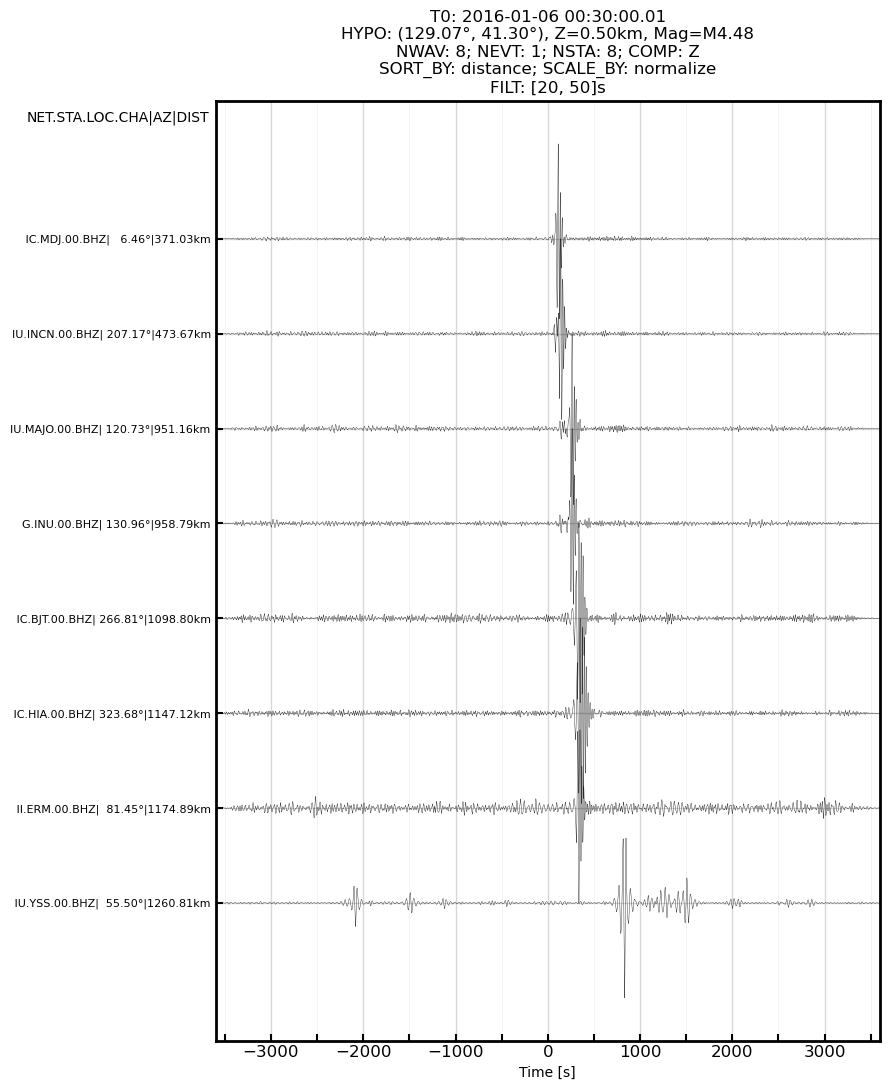

[2025-10-01 12:03:47] - pysep - INFO: finished record section in t=0:00:00.817669s


In [11]:
st = read(plotting["pysep_path"]+'/*BHZ*.sac')
plotw_rs(st=st, cale_by="normalize", scale_by            = 'normalize',
                            amplitude_scale_factor       = 1,
                            time_shift_s                 = None,
                            preprocess                   = 'st',
                            max_traces_per_rs            = None,
                            distance_units               = 'km', 
                            overwrite                    = True,
                            sort_by                    = 'distance',
                            **bandpass)

In [20]:
# CPS is a library that I prepare to calculate Green's function on the fly using CPS code
from CPS import generate_CPS_greens_tensor
from IO import read_stations, read_event

stations = read_stations('DPRK2016a_iris.config')
origin = read_event(evla=41.3001, evlo=129.068, evdp=0.5)

path_to_earth_model = 'MDJ2'
generate_CPS_greens_tensor(origin, stations, path_to_earth_model, t0=0, vred=0)

    Generating Greens's function with CPS

/Users/u7091895/Documents/Research/BayMTI/HiBaysin/examples/MDJ2.mod


# Download broadband data for DPRK2016b test

[2025-10-01 12:21:06] - pysep - DEBUG: `log_level` set to INFO
[2025-10-01 12:21:06] - pysep - INFO: creating event metadata with user parameters
[2025-10-01 12:21:06] - pysep - INFO: event info summary - origin time: 2016-09-09T00:30:01.000000Z; lat=41.30; lon=129.08; depth[km]=0.5; magnitude=4.73
[2025-10-01 12:21:06] - pysep - INFO: full output directory is: /Users/u7091895/Documents/Research/BayMTI/HiBaysin/data/20160909003001000
[2025-10-01 12:21:06] - pysep - INFO: querying IRIS for station metadata



preparing to download data ....


[2025-10-01 12:21:48] - pysep - INFO: collected 473 channels from 158 stations in 4 networks from IRIS
[2025-10-01 12:21:48] - pysep - INFO: 150 traces outside distance bounds [0, 1300]km
[2025-10-01 12:21:48] - pysep - INFO: 0 traces outside azimuth bounds [0, 360]deg
[2025-10-01 12:21:48] - pysep - INFO: querying client 'IRIS' for waveforms
[2025-10-01 12:21:48] - pysep - INFO: querying 8 lines in bulk client request...
[2025-10-01 12:22:46] - pysep - INFO: 24 waveforms returned after query
[2025-10-01 12:22:46] - pysep - INFO: cleaning up channel naming
[2025-10-01 12:22:52] - pysep - INFO: applying linear detrend to all data
[2025-10-01 12:22:52] - pysep - INFO: removing response, output units in: DISP
[2025-10-01 12:22:52] - pysep - INFO: will apply pre-filter: default
[2025-10-01 12:22:55] - pysep - INFO: applying amplitude scale factor: 1
[2025-10-01 12:22:55] - pysep - INFO: trimming start and end times on a per-station basis
[2025-10-01 12:22:55] - pysep - INFO: formatting str

plotting source station map ....


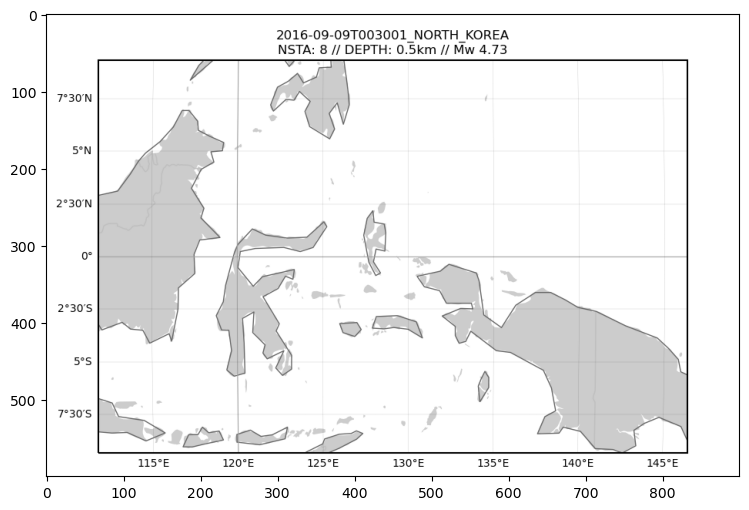

In [13]:
# event information could not be found on catalog

download   = copy(download_defaults)
plotting   = copy(plotting_defaults)

#Based on GA 
event      = dict( origin_time                  = UTCDateTime("2016,9,9,0,30,1"),
                   event_latitude               = 41.2976,
                   event_longitude              = 129.0804,
                   event_depth_km               = 0.5,
                   event_magnitude              = 4.73 )

duration   = dict( seconds_before_ref           = 3600, #reference time is origin time here
                   seconds_after_ref            = 3600 )

download['channels']                            = 'BHZ,BHN,BHE,BH1,BH2' #No space btw each channel code
download['overwrite_event_tag']                 = '20160909003001000'

bandpass   = dict( min_period_s                 = 20,
                   max_period_s                 = 50 )

plotting["pysep_path"]                          = f'{download["output_dir"]}/{download["overwrite_event_tag"]}'

fetch_and_plot(event, duration, download, plotting, bandpass)

[2025-10-01 12:23:01] - pysep - INFO: starting record section plotter
[2025-10-01 12:23:01] - pysep - INFO: checking parameter acceptability
[2025-10-01 12:23:01] - pysep - INFO: getting source-receiver stats
[2025-10-01 12:23:01] - pysep - INFO: calculating source-receiver distance and (back)azimuths
[2025-10-01 12:23:01] - pysep - INFO: preprocessing 8 `st` waveforms
[2025-10-01 12:23:01] - pysep - INFO: applying bandpass filter w/ [0.02, 20]
[2025-10-01 12:23:01] - pysep - INFO: calculating starttime offsets from event origin time 2016-09-09T00:30:01.000000Z
[2025-10-01 12:23:02] - pysep - INFO: determining sort order with parameter: distance
[2025-10-01 12:23:02] - pysep - INFO: determining if any stations/channels should be skipped
[2025-10-01 12:23:02] - pysep - INFO: criteria check will remove 0/8 traces
[2025-10-01 12:23:02] - pysep - INFO: determining y-axis positioning for sort: distance
[2025-10-01 12:23:02] - pysep - INFO: determining amplitude scaling w.r.t st with: 'norma

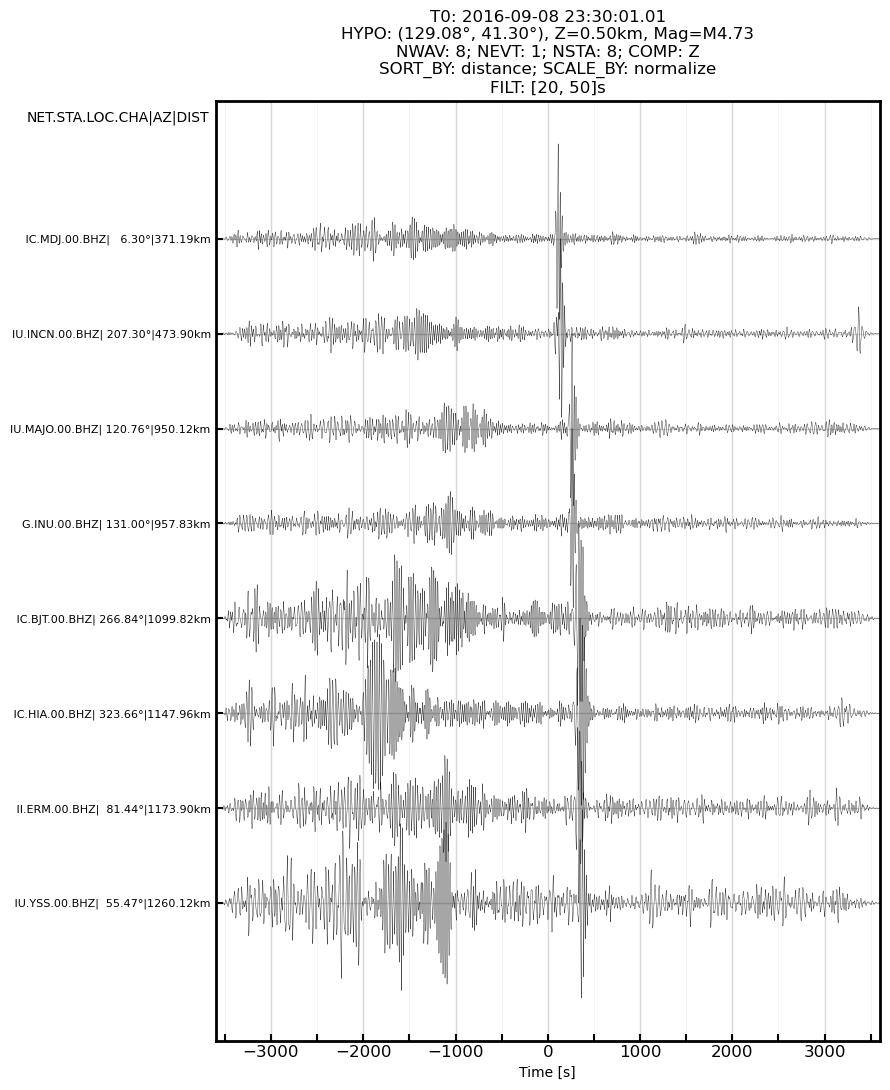

[2025-10-01 12:23:02] - pysep - INFO: finished record section in t=0:00:00.762579s


In [14]:
st = read(plotting["pysep_path"]+'/*BHZ*.sac')
plotw_rs(st=st, cale_by="normalize", scale_by            = 'normalize',
                            amplitude_scale_factor       = 1,
                            time_shift_s                 = None,
                            preprocess                   = 'st',
                            max_traces_per_rs            = None,
                            distance_units               = 'km', 
                            overwrite                    = True,
                            sort_by                    = 'distance',
                            **bandpass)

In [21]:
# CPS is a library that I prepare to calculate Green's function on the fly using CPS code
from CPS import generate_CPS_greens_tensor
from IO import read_stations, read_event

stations = read_stations('DPRK2016b_iris.config')
origin = read_event(evla=41.2976, evlo=129.0804, evdp=0.5)

path_to_earth_model = 'MDJ2'
generate_CPS_greens_tensor(origin, stations, path_to_earth_model, t0=0, vred=0)

    Generating Greens's function with CPS

/Users/u7091895/Documents/Research/BayMTI/HiBaysin/examples/MDJ2.mod


# Download broadband data for DPRK2009 test

[2025-10-01 13:13:10] - pysep - DEBUG: `log_level` set to INFO
[2025-10-01 13:13:10] - pysep - INFO: creating event metadata with user parameters
[2025-10-01 13:13:10] - pysep - INFO: event info summary - origin time: 2009-05-25T00:54:43.000000Z; lat=41.29; lon=129.08; depth[km]=0.5; magnitude=4.39
[2025-10-01 13:13:10] - pysep - INFO: full output directory is: /Users/u7091895/Documents/Research/BayMTI/HiBaysin/data/20090525005443000
[2025-10-01 13:13:10] - pysep - INFO: querying IRIS for station metadata



preparing to download data ....


[2025-10-01 13:14:18] - pysep - INFO: collected 423 channels from 143 stations in 4 networks from IRIS
[2025-10-01 13:14:19] - pysep - INFO: 135 traces outside distance bounds [0, 1300]km
[2025-10-01 13:14:20] - pysep - INFO: 0 traces outside azimuth bounds [0, 360]deg
[2025-10-01 13:14:20] - pysep - INFO: querying client 'IRIS' for waveforms
[2025-10-01 13:14:20] - pysep - INFO: querying 8 lines in bulk client request...
[2025-10-01 13:15:01] - pysep - INFO: 30 waveforms returned after query
[2025-10-01 13:15:01] - pysep - INFO: cleaning up channel naming
[2025-10-01 13:15:08] - pysep - INFO: applying linear detrend to all data
[2025-10-01 13:15:08] - pysep - INFO: removing response, output units in: DISP
[2025-10-01 13:15:08] - pysep - INFO: will apply pre-filter: default
[2025-10-01 13:15:12] - pysep - INFO: applying amplitude scale factor: 1
[2025-10-01 13:15:12] - pysep - INFO: trimming start and end times on a per-station basis
[2025-10-01 13:15:12] - pysep - INFO: IC.HIA.00.BHE 

plotting source station map ....


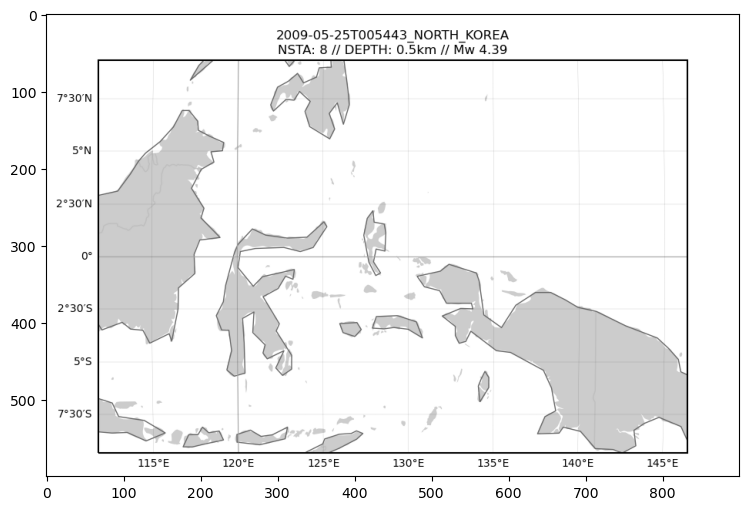

In [16]:
# event information could not be found on catalog

download   = copy(download_defaults)
plotting   = copy(plotting_defaults)

#Based on GA 
event      = dict( origin_time                  = UTCDateTime("2009,5,25,0,54,43"),
                   event_latitude               = 41.2943,
                   event_longitude              = 129.0778,
                   event_depth_km               = 0.5,
                   event_magnitude              = 4.39 )

duration   = dict( seconds_before_ref           = 3600, #reference time is origin time here
                   seconds_after_ref            = 3600 )

download['channels']                            = 'BHZ,BHN,BHE,BH1,BH2' #No space btw each channel code
download['overwrite_event_tag']                 = '20090525005443000'

bandpass   = dict( min_period_s                 = 20,
                   max_period_s                 = 50 )

plotting["pysep_path"]                          = f'{download["output_dir"]}/{download["overwrite_event_tag"]}'

fetch_and_plot(event, duration, download, plotting, bandpass)

[2025-10-01 13:15:39] - pysep - INFO: starting record section plotter
[2025-10-01 13:15:39] - pysep - INFO: checking parameter acceptability
[2025-10-01 13:15:39] - pysep - INFO: getting source-receiver stats
[2025-10-01 13:15:39] - pysep - INFO: calculating source-receiver distance and (back)azimuths
[2025-10-01 13:15:39] - pysep - INFO: preprocessing 8 `st` waveforms
[2025-10-01 13:15:39] - pysep - INFO: applying bandpass filter w/ [0.02, 20]
[2025-10-01 13:15:39] - pysep - INFO: calculating starttime offsets from event origin time 2009-05-25T00:54:43.000000Z
[2025-10-01 13:15:39] - pysep - INFO: determining sort order with parameter: distance
[2025-10-01 13:15:39] - pysep - INFO: determining if any stations/channels should be skipped
[2025-10-01 13:15:39] - pysep - INFO: criteria check will remove 0/8 traces
[2025-10-01 13:15:39] - pysep - INFO: determining y-axis positioning for sort: distance
[2025-10-01 13:15:39] - pysep - INFO: determining amplitude scaling w.r.t st with: 'norma

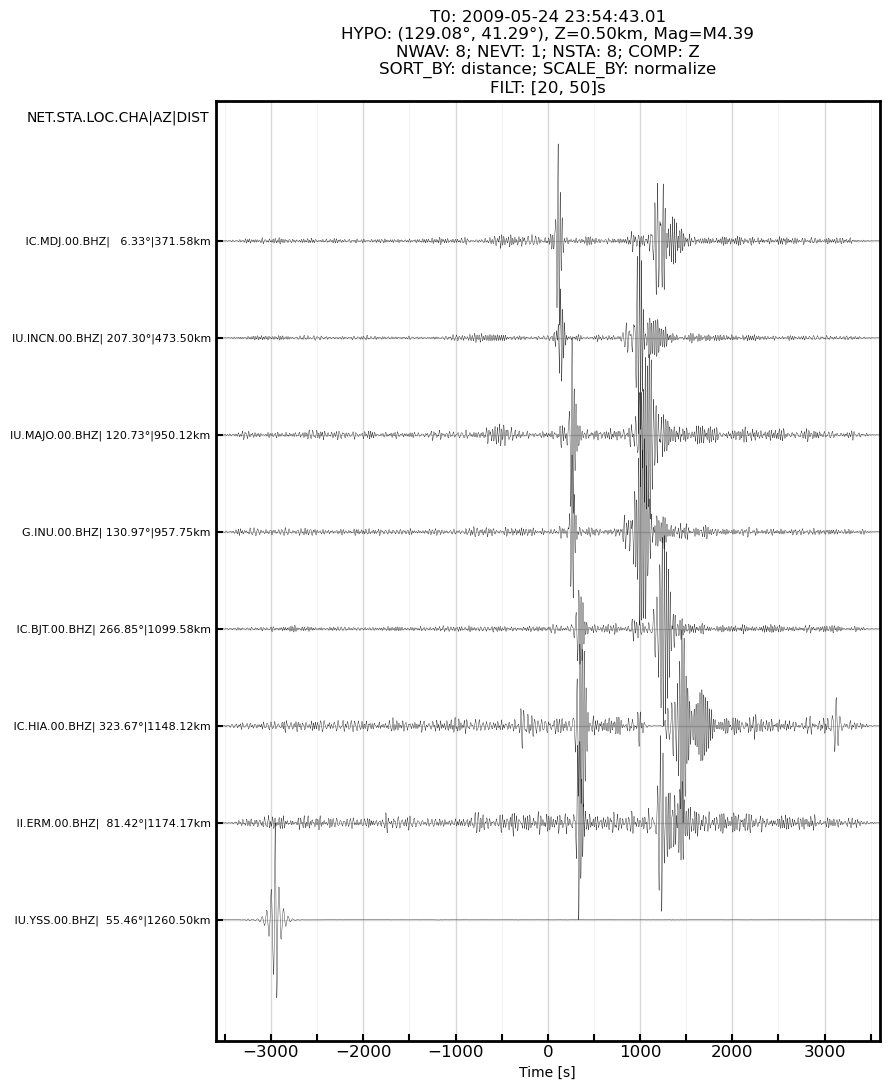

[2025-10-01 13:15:40] - pysep - INFO: finished record section in t=0:00:00.784213s


In [17]:
st = read(plotting["pysep_path"]+'/*BHZ*.sac')
plotw_rs(st=st, cale_by="normalize", scale_by            = 'normalize',
                            amplitude_scale_factor       = 1,
                            time_shift_s                 = None,
                            preprocess                   = 'st',
                            max_traces_per_rs            = None,
                            distance_units               = 'km', 
                            overwrite                    = True,
                            sort_by                    = 'distance',
                            **bandpass)

In [19]:
# CPS is a library that I prepare to calculate Green's function on the fly using CPS code
from CPS import generate_CPS_greens_tensor
from IO import read_stations, read_event

stations = read_stations('DPRK2009_iris.config')
origin = read_event(evla=41.2943, evlo=129.0778, evdp=0.5)

path_to_earth_model = 'MDJ2'
generate_CPS_greens_tensor(origin, stations, path_to_earth_model, t0=0, vred=0)

    Generating Greens's function with CPS

/Users/u7091895/Documents/Research/BayMTI/HiBaysin/examples/MDJ2.mod
